In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [114]:
# Cleaning the data
df["Age"] = df["Age"].fillna(df["Age"].mean())
df.dropna(subset=["Embarked"], inplace=True)
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q


In [115]:
# Explore the data
print("Survived:", (df["Survived"] == 1).sum())
print("Not Survived:", (df["Survived"] == 0).sum())

Survived: 340
Not Survived: 549


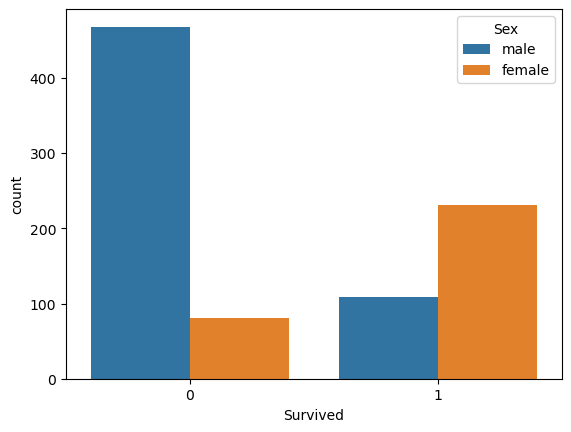

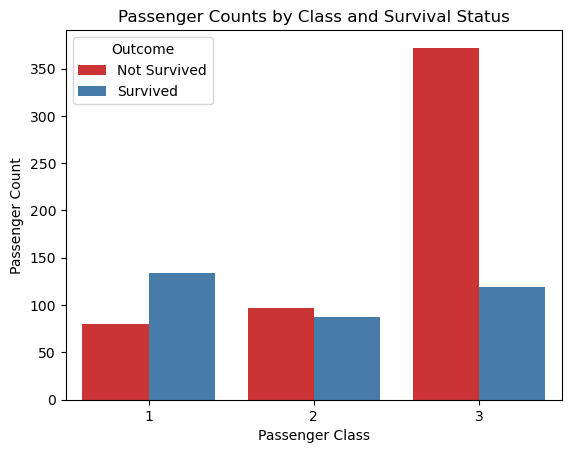

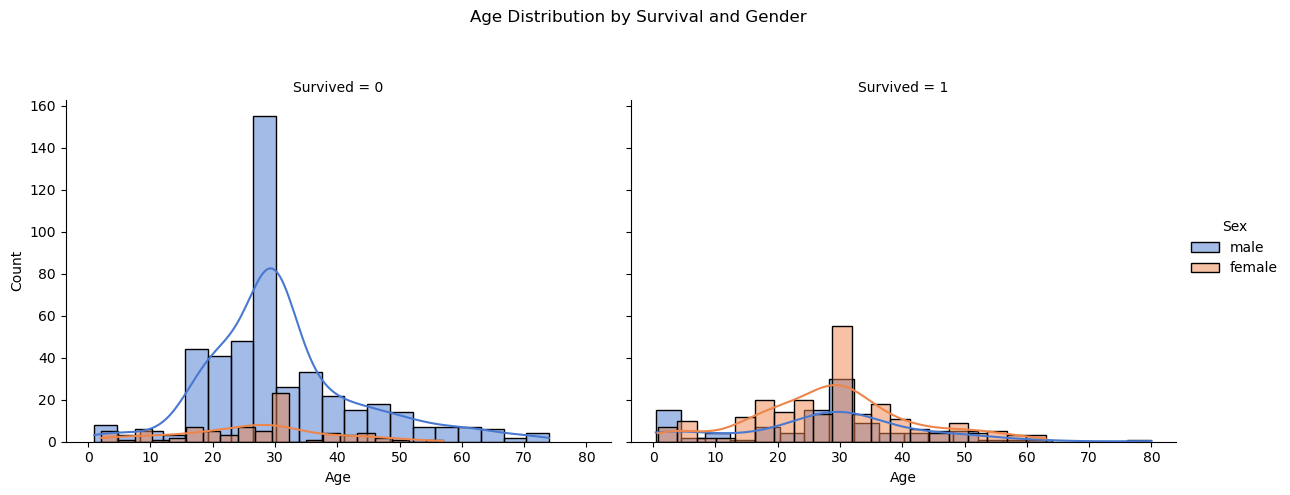

In [116]:
### Exploring the data by the features
#Gender
sns.countplot(x="Survived", hue="Sex", data=df)
plt.show()

#Class
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set1")
plt.title("Passenger Counts by Class and Survival Status")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.legend(title="Outcome", labels=["Not Survived", "Survived"])
plt.show()

#Age and Gender
g = sns.FacetGrid(df, col="Survived", hue="Sex", height=5, aspect=1.2, palette="muted")
g.map(sns.histplot, "Age", bins=20, alpha=0.5, kde=True)
g.add_legend()
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Age Distribution by Survival and Gender")
plt.show()

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# Convert gender to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
features = ['Pclass', 'Sex', 'Age', 'Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Interpret Coefficients
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- Feature Coefficients ---")
print(importance.to_string(index=False))

--- Feature Coefficients ---
Feature  Coefficient
    Sex     2.522658
   Fare    -0.000010
    Age    -0.036123
 Pclass    -1.166397


In [121]:
y_pred = model.predict(X_test)

# Create a comparison DataFrame for the first 10 passengers
comparison_df = pd.DataFrame({
    'Actual Survival': y_test.iloc[:10].values,
    'Predicted Survival': y_pred[:10]
})

print("\n--- Predicted vs. Actual (First 10 Passengers) ---")
print(comparison_df)
print("Accuracy:",(comparison_df['Actual Survival'] == comparison_df['Predicted Survival']).sum()/10)


--- Predicted vs. Actual (First 10 Passengers) ---
   Actual Survival  Predicted Survival
0                0                   0
1                1                   1
2                1                   1
3                0                   0
4                1                   1
5                1                   0
6                0                   0
7                0                   0
8                1                   1
9                1                   1
Accuracy: 0.9



Model Accuracy: 79.21%


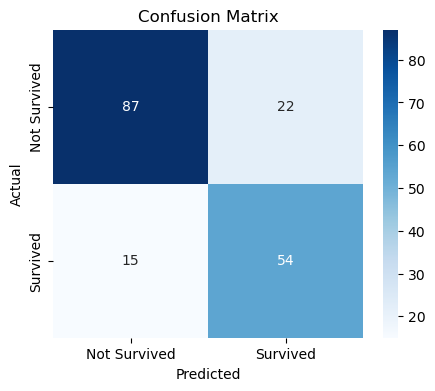

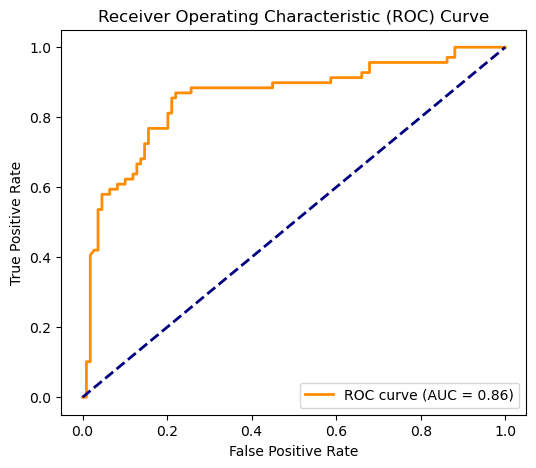

In [126]:
#Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc:.2%}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC Curve
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()